<a href="https://colab.research.google.com/github/Soco-Roman/GISLatam_2026/blob/main/Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Visualization of Traffic Incident Concentration

This notebook performs a spatial analysis of the INEGI traffic incident database (ATUS) to identify the areas that concentrate traffic incidents with the highest number of injured people in Mexico City.

contextily not found. Installing...


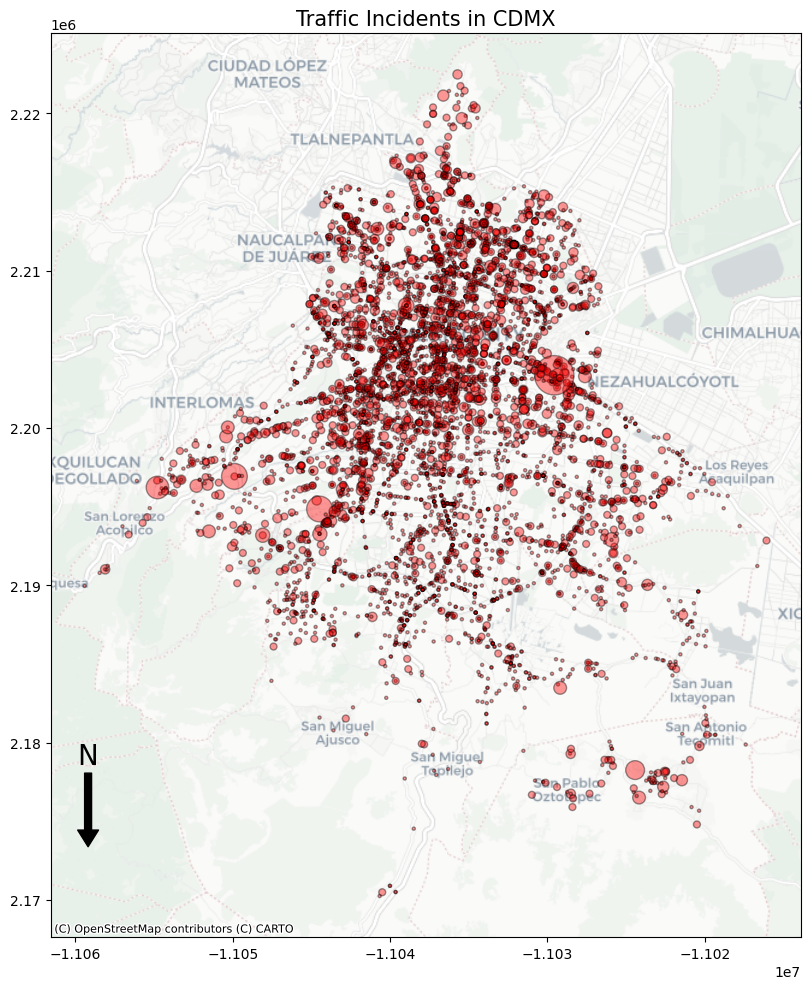

In [1]:
import geopandas
import matplotlib.pyplot as plt

# 1. Setup: Install contextily if not already available
try:
    import contextily as cx
except ImportError:
    print("contextily not found. Installing...")
    !pip install contextily
    import contextily as cx

# 2. Load Data: Read the GeoJSON file
incident_gdf = geopandas.read_file("/content/atus_cdmx.geojson")

# 3. Reprojection: Convert CRS to Web Mercator (EPSG:3857)
incident_gdf = incident_gdf.to_crs(epsg=3857)

# 4. Plot Setup: Create a plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# 6. Dynamic Sizing: Calculate marker size based on TOTHERIDOS
# Ensure TOTHERIDOS is numeric and handle potential NaNs by filling with 0
incident_gdf['TOTHERIDOS'] = incident_gdf['TOTHERIDOS'].fillna(0).astype(int)
incident_gdf['markersize'] = incident_gdf['TOTHERIDOS'] * 20 + 5

# 5. Data Visualization: Plot incidents as scatter points
incident_gdf.plot(ax=ax, marker='o', color='red', edgecolor='k', alpha=0.4,
                  markersize=incident_gdf['markersize'], legend=True,
                  label='Traffic Incidents')

# 7. Basemap: Add 'CartoDB Positron' basemap
cx.add_basemap(ax, crs=incident_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

# 8. Map Elements: Add a North arrow
x, y, arrow_length = 0.05, 0.1, 0.1 # Position and length of the arrow (relative to axes)
ax.annotate('N', xy=(x, y), xytext=(x, y + arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20, color='black',
            xycoords=ax.transAxes)

# 9. Formatting: Add title and maintain axis coordinates
ax.set_title('Traffic Incidents in CDMX', fontsize=15)
ax.set_axis_on() # Ensure axes are visible

plt.tight_layout()
plt.show()